In [1]:
pip install pandas numpy matplotlib seaborn pandasql openpyxl scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# Load dataset - try both possible file names
try:
    df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
    print("✅ Loaded Year 2010-2011 sheet")
except:
    try:
        df = pd.read_excel('online_retail_II.xlsx')
        print("✅ Loaded default sheet")
    except:
        df = pd.read_csv('online_retail_II.csv')
        print("✅ Loaded CSV file")

# First look
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

✅ Loaded CSV file

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Data types:
Invoice         object
StockCode  

In [3]:
# ---- 1. Drop rows with missing Customer ID (can't segment without it)
df = df.dropna(subset=['Customer ID'])
print(f"After dropping missing Customer IDs: {df.shape}")

# ---- 2. Fix data types
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# ---- 3. Remove cancelled orders (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# ---- 4. Remove negative/zero quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print(f"After removing invalid quantities/prices: {df.shape}")

# ---- 5. Drop missing descriptions
df = df.dropna(subset=['Description'])
print(f"After dropping missing descriptions: {df.shape}")

# ---- 6. Add Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# ---- 7. Check date range
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total customers: {df['Customer ID'].nunique()}")
print(f"Total transactions: {df.shape[0]}")
print(f"Total revenue: £{df['Revenue'].sum():,.2f}")
print(f"\n✅ Data cleaned successfully!")

After dropping missing Customer IDs: (824364, 8)
After removing cancellations: (805620, 8)
After removing invalid quantities/prices: (805549, 8)
After dropping missing descriptions: (805549, 8)

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total customers: 5878
Total transactions: 805549
Total revenue: £17,743,429.18

✅ Data cleaned successfully!


In [5]:
# ---- RFM Analysis

# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# ---- Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(f"\nRFM Table (first 5 rows):")
print(rfm.head())
print(f"\nRFM Stats:")
print(rfm.describe())

# ---- Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

# ---- Combined RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['Total_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# ---- Assign Segments
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(f"\n✅ RFM Scoring complete!")
print(f"\nSegment breakdown:")
print(rfm['Segment'].value_counts())
print(f"\nRevenue by Segment:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).apply(lambda x: f"£{x:,.0f}"))

Reference date: 2011-12-10 12:50:00

RFM Table (first 5 rows):
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40

RFM Stats:
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000

✅ RFM Scoring complete!

Segment breakdown:
Segment
Champions              1300
Lost                   12

In [7]:
# ---- SQL Analysis on RFM data

# Query 1: Segment Summary
q1 = """
SELECT 
    Segment,
    COUNT(*) as Total_Customers,
    ROUND(AVG(Recency), 0) as Avg_Recency_Days,
    ROUND(AVG(Frequency), 1) as Avg_Frequency,
    ROUND(AVG(Monetary), 2) as Avg_Revenue,
    ROUND(SUM(Monetary), 2) as Total_Revenue,
    ROUND(SUM(Monetary) * 100.0 / (SELECT SUM(Monetary) FROM rfm), 1) as Revenue_Pct
FROM rfm
GROUP BY Segment
ORDER BY Total_Revenue DESC
"""
result1 = pysqldf(q1)
print("=== SEGMENT SUMMARY ===")
print(result1)

# Query 2: Top 10 Champions by Revenue
q2 = """
SELECT 
    "Customer ID",
    Recency,
    Frequency,
    ROUND(Monetary, 2) as Total_Revenue,
    RFM_Score
FROM rfm
WHERE Segment = 'Champions'
ORDER BY Monetary DESC
LIMIT 10
"""
result2 = pysqldf(q2)
print("\n=== TOP 10 CHAMPIONS ===")
print(result2)

# Query 3: At Risk customers - high value ones
q3 = """
SELECT 
    "Customer ID",
    Recency,
    Frequency,
    ROUND(Monetary, 2) as Total_Revenue,
    Segment
FROM rfm
WHERE Segment = 'At Risk'
AND Monetary > 1000
ORDER BY Monetary DESC
LIMIT 10
"""
result3 = pysqldf(q3)
print("\n=== HIGH VALUE AT-RISK CUSTOMERS ===")
print(result3)

# Query 4: Revenue concentration (Pareto check)
q4 = """
SELECT
    CASE 
        WHEN Segment = 'Champions' THEN '🏆 Champions'
        WHEN Segment = 'Loyal Customers' THEN '💛 Loyal'
        WHEN Segment = 'At Risk' THEN '⚠️ At Risk'
        WHEN Segment = 'Lost' THEN '💔 Lost'
        WHEN Segment = 'Potential Loyalists' THEN '🌱 Potential'
        ELSE '🔄 Needs Attention'
    END as Segment_Label,
    COUNT(*) as Customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM rfm), 1) as Customer_Pct,
    ROUND(SUM(Monetary), 0) as Revenue,
    ROUND(SUM(Monetary) * 100.0 / (SELECT SUM(Monetary) FROM rfm), 1) as Revenue_Pct
FROM rfm
GROUP BY Segment
ORDER BY Revenue DESC
"""
result4 = pysqldf(q4)
print("\n=== REVENUE CONCENTRATION ===")
print(result4)

# Query 5: Avg order value and frequency by segment
q5 = """
SELECT
    Segment,
    ROUND(AVG(Monetary / Frequency), 2) as Avg_Order_Value,
    ROUND(AVG(Frequency), 1) as Avg_Orders,
    ROUND(AVG(Recency), 0) as Avg_Days_Since_Purchase,
    COUNT(*) as Total_Customers
FROM rfm
GROUP BY Segment
ORDER BY Avg_Order_Value DESC
"""
result5 = pysqldf(q5)
print("\n=== AVG ORDER VALUE BY SEGMENT ===")
print(result5)

=== SEGMENT SUMMARY ===
               Segment  Total_Customers  Avg_Recency_Days  Avg_Frequency  \
0            Champions             1300              20.0           17.1   
1      Loyal Customers             1134              73.0            5.9   
2              At Risk              615             360.0            5.6   
3      Needs Attention             1111             220.0            2.2   
4  Potential Loyalists              443              28.0            1.5   
5                 Lost             1275             468.0            1.2   

   Avg_Revenue  Total_Revenue  Revenue_Pct  
0      9329.32    12128115.56         68.4  
1      2295.58     2603183.47         14.7  
2      2517.23     1548098.81          8.7  
3       667.64      741749.47          4.2  
4       890.83      394638.61          2.2  
5       256.98      327643.25          1.8  

=== TOP 10 CHAMPIONS ===
   Customer ID  Recency  Frequency  Total_Revenue RFM_Score
0        18102        1        145      60

C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\3273218312.py:86: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\3273218312.py:86: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\3273218312.py:86: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\3273218312.py:86: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\3273218312.py:86: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\hardi\AppData\Local\Temp\ipykernel_22924\327

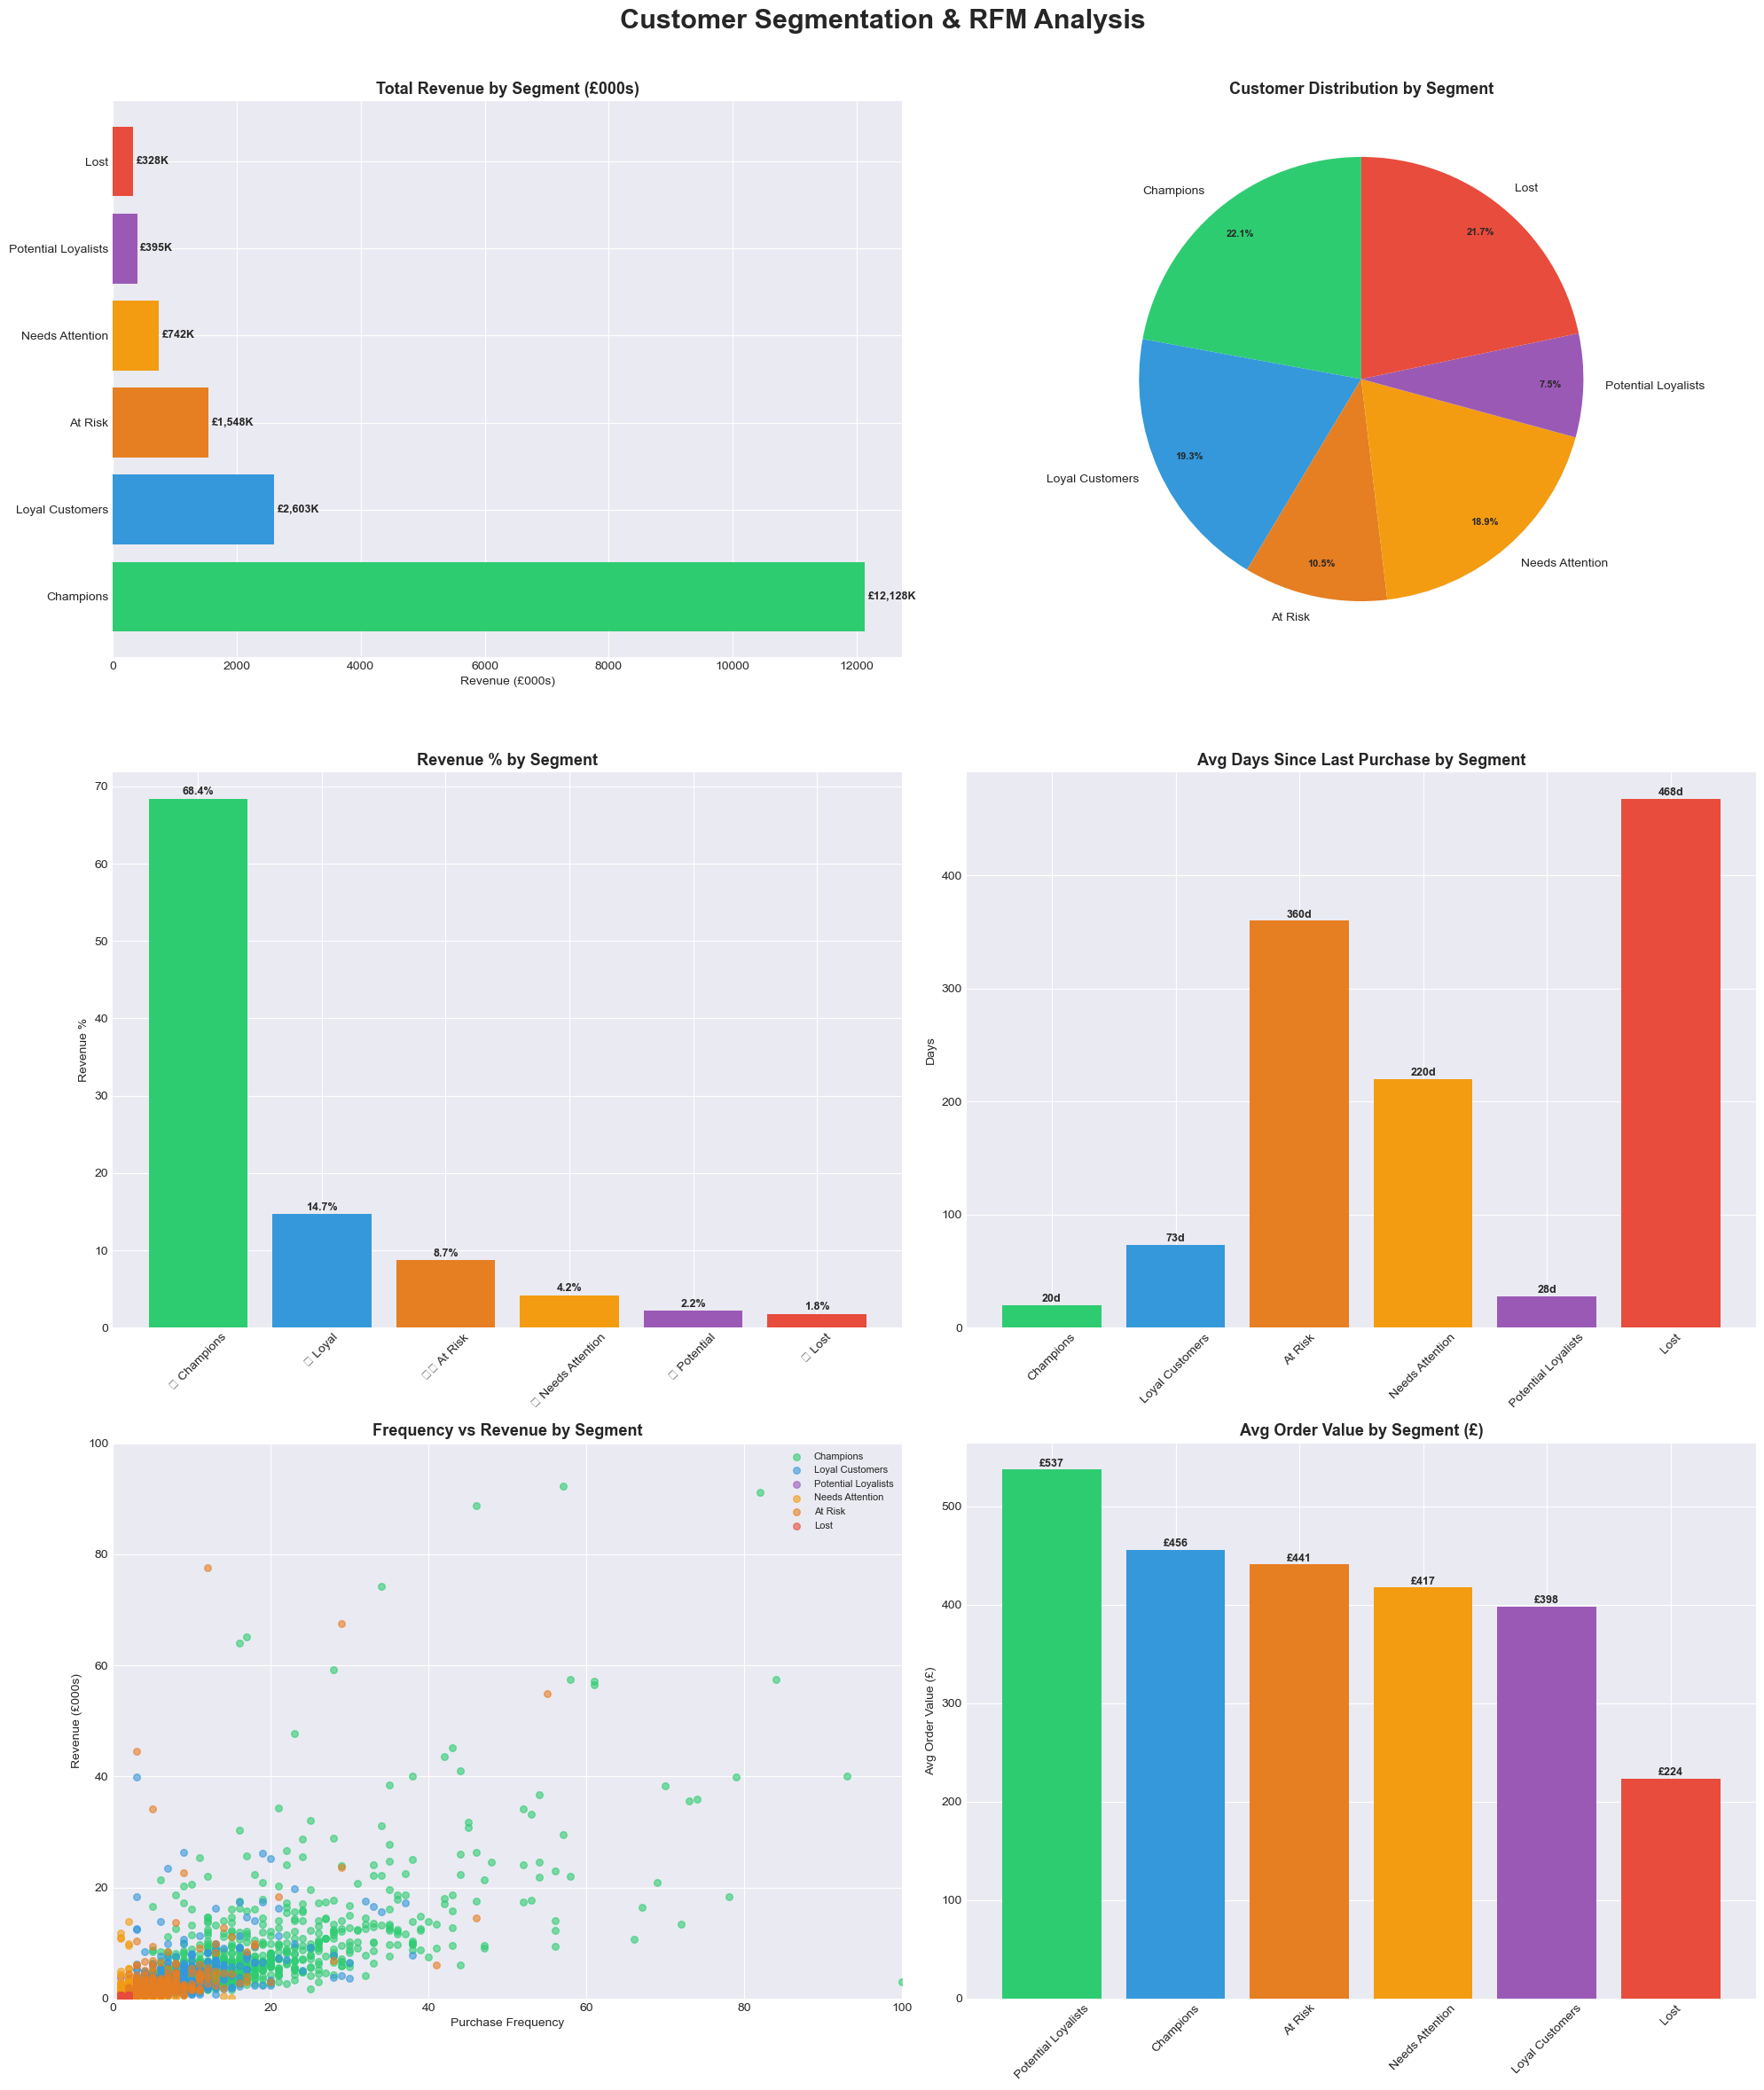

✅ Charts saved!


In [9]:
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Customer Segmentation & RFM Analysis', fontsize=22, fontweight='bold', y=0.98)

colors_seg = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'Potential Loyalists': '#9b59b6',
    'Needs Attention': '#f39c12',
    'At Risk': '#e67e22',
    'Lost': '#e74c3c'
}
seg_colors = [colors_seg[s] for s in result1['Segment']]

# ---- CHART 1: Revenue by Segment (Horizontal Bar)
ax1 = fig.add_subplot(3, 2, 1)
bars = ax1.barh(result1['Segment'], result1['Total_Revenue']/1000,
                color=seg_colors)
ax1.set_title('Total Revenue by Segment (£000s)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Revenue (£000s)')
for bar, val in zip(bars, result1['Total_Revenue']/1000):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}K', va='center', fontsize=9, fontweight='bold')

# ---- CHART 2: Customer Count by Segment (Donut)
ax2 = fig.add_subplot(3, 2, 2)
wedges, texts, autotexts = ax2.pie(
    result1['Total_Customers'],
    labels=result1['Segment'],
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90,
    pctdistance=0.85
)
ax2.set_title('Customer Distribution by Segment', fontsize=13, fontweight='bold')
for text in autotexts:
    text.set_fontsize(8)
    text.set_fontweight('bold')

# ---- CHART 3: Revenue Concentration (Pareto-style)
ax3 = fig.add_subplot(3, 2, 3)
bars3 = ax3.bar(result4['Segment_Label'], result4['Revenue_Pct'],
                color=seg_colors)
ax3.set_title('Revenue % by Segment', fontsize=13, fontweight='bold')
ax3.set_ylabel('Revenue %')
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, result4['Revenue_Pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=9, fontweight='bold')

# ---- CHART 4: Avg Recency by Segment (Days since last purchase)
ax4 = fig.add_subplot(3, 2, 4)
bars4 = ax4.bar(result1['Segment'], result1['Avg_Recency_Days'],
                color=seg_colors)
ax4.set_title('Avg Days Since Last Purchase by Segment', fontsize=13, fontweight='bold')
ax4.set_ylabel('Days')
ax4.tick_params(axis='x', rotation=45)
for bar, val in zip(bars4, result1['Avg_Recency_Days']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{int(val)}d', ha='center', fontsize=9, fontweight='bold')

# ---- CHART 5: RFM Scatter — Frequency vs Monetary colored by Segment
ax5 = fig.add_subplot(3, 2, 5)
for segment, color in colors_seg.items():
    seg_data = rfm[rfm['Segment'] == segment]
    ax5.scatter(seg_data['Frequency'], seg_data['Monetary']/1000,
                c=color, label=segment, alpha=0.6, s=30)
ax5.set_title('Frequency vs Revenue by Segment', fontsize=13, fontweight='bold')
ax5.set_xlabel('Purchase Frequency')
ax5.set_ylabel('Revenue (£000s)')
ax5.legend(fontsize=8)
ax5.set_ylim(0, 100)
ax5.set_xlim(0, 100)

# ---- CHART 6: Avg Order Value by Segment
ax6 = fig.add_subplot(3, 2, 6)
bars6 = ax6.bar(result5['Segment'], result5['Avg_Order_Value'],
                color=seg_colors)
ax6.set_title('Avg Order Value by Segment (£)', fontsize=13, fontweight='bold')
ax6.set_ylabel('Avg Order Value (£)')
ax6.tick_params(axis='x', rotation=45)
for bar, val in zip(bars6, result5['Avg_Order_Value']):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('customer_segmentation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [11]:
# Fix - remove emojis from segment labels in result4
result4['Segment_Label'] = result4['Segment_Label'].str.replace('🏆 ', '').str.replace('💛 ', '').str.replace('⚠️ ', '').str.replace('💔 ', '').str.replace('🌱 ', '').str.replace('🔄 ', '')

print("✅ Fixed!")
print(result4['Segment_Label'].tolist())

✅ Fixed!
['Champions', 'Loyal', 'At Risk', 'Needs Attention', 'Potential', 'Lost']


In [13]:
# Export to Excel
with pd.ExcelWriter('segmentation_data.xlsx', engine='openpyxl') as writer:
    rfm.to_excel(writer, sheet_name='RFM_Scores', index=False)
    result1.to_excel(writer, sheet_name='Segment_Summary', index=False)
    result4.to_excel(writer, sheet_name='Revenue_Concentration', index=False)
    result5.to_excel(writer, sheet_name='Avg_Order_Value', index=False)

print("✅ Excel exported successfully!")
print("📁 Check your customer_segmentation folder")

✅ Excel exported successfully!
📁 Check your customer_segmentation folder
